In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from numba import njit
import time
from IPython.display import HTML

# Próba 2


In [2]:
def siatka(n):
  return np.random.default_rng().integers(0, 2, (n,n))*2-1
siatka(5)

array([[ 1, -1, -1, -1,  1],
       [ 1, -1, -1, -1,  1],
       [-1, -1,  1,  1, -1],
       [ 1,  1,  1,  1, -1],
       [-1,  1, -1,  1,  1]])

In [3]:
def suma_sasiad(siatka, x, y, n): #x jest w poziomie, y w pionie
  suma = 0
  for i in range(3):
    for j in range(3):
      #print(a[i,j])
      suma += siatka[(y+i-1) % n, (x+j-1) % n]
  suma -= siatka[y,x]
  return suma
suma_sasiad(siatka(5), 2, 1, 5)

np.int64(0)

In [4]:
def suma_calk(siatka):
  n = len(siatka)
  suma = 0
  for i in range(n):
    for j in range(n):
      suma += suma_sasiad(siatka, i, j, n)
  return suma
suma_calk(siatka(5))

np.int64(24)

In [5]:
def E(siatka, J, B):
  n = len(siatka)
  return - B * siatka.sum() - J * suma_calk(siatka)
E(siatka(5), 2, 0)

np.int64(80)

In [6]:
def dE(siatka, cords, J, B):
  n = len(siatka)
  x = cords[1]
  y = cords[0]
  return 2 * siatka[y, x] * (J * suma_sasiad(siatka, x, y, n) + B)
dE(siatka(5), [2,3], 2, 0)

np.int64(0)

In [7]:
def makro(siatka, J, B, beta):
  n = len(siatka)
  H = E(siatka, J, B)
  siat = np.copy(siatka)
  for i in range(n**2):
      cords = [random.randint(0,n-1),random.randint(0,n-1)]
      d = dE(siat, cords, J, B)
      if d < 0:
          siat[cords[0]][cords[1]] *= -1
          H += d
      else:
          if np.exp(-beta * d) >= random.random():
              siat[cords[0]][cords[1]] *= -1
              H += d
  M = siat.sum() / n**2
  return siat, E(siat, J, B), M
makro(siatka(5), 2, 0, .1000)

(array([[-1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1],
        [-1,  1,  1, -1,  1],
        [ 1,  1,  1,  1, -1],
        [ 1, -1,  1,  1,  1]]),
 np.int64(48),
 np.float64(-0.12))

In [8]:
def Sim(n, J, B, beta, N):
  Siat = siatka(n)
  Mak = [Siat]
  Energia = [E(Siat, J, B)]
  Magnetyzacja = [Siat.sum() / n**2]
  for i in range(N):
    #print(Siat)
    Siat, Ene, Mag = makro(Siat, J, B, beta)
    Mak.append(Siat)
    Energia.append(Ene)
    Magnetyzacja.append(Mag)
    #print(Siat)
  plt.subplot(2,1,1)
  plt.plot(range(N+1), Energia)
  plt.xlabel('Makrokrok')
  plt.ylabel('Energia')
  plt.subplot(2,1,2)
  plt.plot(range(N+1), Magnetyzacja)
  plt.ylim(-1, 1)
  plt.xlabel('Makrokrok')
  plt.ylabel('Magnetyzacja')
  return Mak, Energia, Magnetyzacja

Czas bez numba = 27.411741733551025


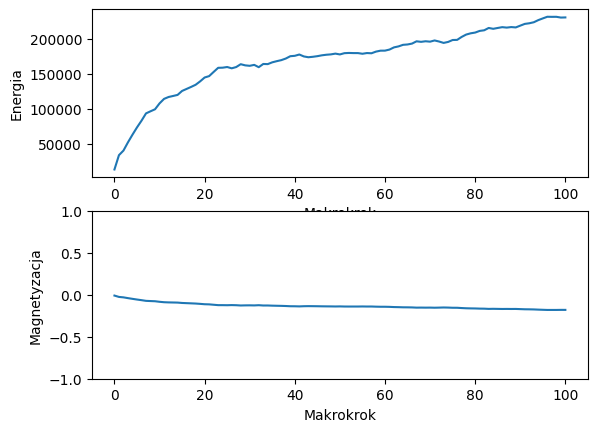

In [9]:
N = 100
n = 200

start = time.time()
Stany, Energia, Magnetyzacja = Sim(n, 4, 0, 10000, N)
end = time.time()
print("Czas bez numba = %s" % (end - start))

In [10]:
E(Stany[0], 4, 0) == Energia[0]

np.True_

In [11]:
E(Stany[1], 4, 0) == Energia[1]

np.True_

In [12]:
def animacja(Stany):
  n = len(Stany[0])
  N = len(Stany)
  rows, cols = n, n

  fig = plt.figure(figsize=(4, 4))
  fig.subplots_adjust(0, 0, 1, 1)
  plt.axis('off')
  im = plt.imshow(Stany[0], cmap='gray', interpolation='nearest', vmin=-1, vmax=1)
  plt.close()
  
  def animate(frame):
      im.set_array(Stany[frame])
      #plt.title(f'Czarny = -1, Biały = 1, Makrostan nr. {frame}')
      return [im]

  ani = animation.FuncAnimation(fig, animate, frames=N, interval=100, blit=True, repeat=True)

  #ani.save("siatka.gif", writer="pillow", fps=10)

  return HTML(ani.to_jshtml())

In [13]:
animacja(Stany)

# Numba

In [15]:
def siatka(n):
  return (np.random.randint(0, 2, (n,n))*2-1).astype(float)

In [16]:
@njit
def suma_sasiad(siatka, x, y, n): #x jest w poziomie, y w pionie
  suma = 0
  for i in range(3):
    for j in range(3):
      #print(a[i,j])
      suma += siatka[(y+i-1) % n, (x+j-1) % n]
  suma -= siatka[y,x]
  return suma

In [17]:
@njit
def suma_calk(siatka):
  n = len(siatka)
  suma = 0
  for i in range(n):
    for j in range(n):
      suma += suma_sasiad(siatka, i, j, n)
  return suma

In [18]:
@njit
def E(siatka, J, B):
  n = len(siatka)
  return - B * siatka.sum() - J * suma_calk(siatka)

In [19]:
@njit
def dE(siatka, cords, J, B):
  n = len(siatka)
  x = cords[1]
  y = cords[0]
  return 2 * siatka[y, x] * (J * suma_sasiad(siatka, x, y, n) + B)

In [20]:
@njit
def makro(siatka, J, B, beta, E):
  n = len(siatka)
  H = E
  siat = np.copy(siatka)
  for i in range(n**2):
      cords = [random.randint(0,n-1),random.randint(0,n-1)]
      d = dE(siat, cords, J, B)
      if d < 0:
          siat[cords[0]][cords[1]] *= -1
          H += d
      else:
          if np.exp(-beta * d) >= random.random():
              siat[cords[0]][cords[1]] *= -1
              H += d
  M = siat.sum() / n**2
  return siat, H, M

In [21]:
@njit
def Sim(siat, J, B, beta, N, E):
  n = len(siat)
  Siat = siat
  Mak = [Siat]
  Energia = [E]
  Magnetyzacja = [Siat.sum() / n**2]
  for i in range(N):
    #print(Siat)
    Siat, Ene, Mag = makro(Siat, J, B, beta, Energia[i])
    Mak.append(Siat)
    Energia.append(Ene)
    Magnetyzacja.append(Mag)
    #print(Siat)
  return Mak, Energia, Magnetyzacja

In [22]:
N = 100
n = 200
test = siatka(n)
J = 1
B = 0
H = E(test, J, B)

start = time.time()
Stany, Energia, Magnetyzacja = Sim(test, J, B, 10000, N, H)
end = time.time()
print("Czas z numba (pierwsze) = %s" % (end - start))

start = time.time()
Stany, Energia, Magnetyzacja = Sim(test, J, B, 10000, N, H)
end = time.time()
print("Czas z numba (drugie) = %s" % (end - start))

Czas z numba (pierwsze) = 1.3539669513702393
Czas z numba (drugie) = 0.48212528228759766


In [23]:
def animacja(Stany):
  n = len(Stany[0])
  N = len(Stany)
  rows, cols = n, n

  fig = plt.figure(figsize=(4, 4))
  fig.subplots_adjust(0, 0, 1, 1)
  plt.axis('off')
  im = plt.imshow(Stany[0], cmap='gray', interpolation='nearest', vmin=-1, vmax=1)
  plt.close()

  def animate(frame):
      im.set_array(Stany[frame])
      #plt.title(f'Czarny = -1, Biały = 1, Makrostan nr. {frame}')
      return [im]

  ani = animation.FuncAnimation(fig, animate, frames=N, interval=100, blit=True, repeat=True)

  #ani.save("siatka.gif", writer="pillow", fps=10)

  plt.show()

  return HTML(ani.to_jshtml())

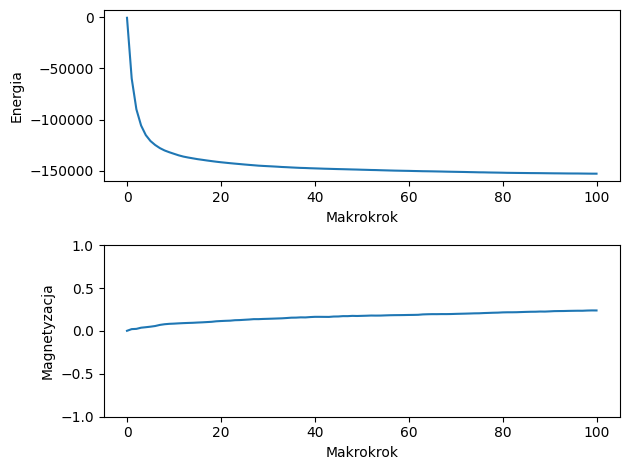

In [24]:
plt.subplot(2,1,1)
plt.plot(range(N+1), Energia)
plt.xlabel('Makrokrok')
plt.ylabel('Energia')
plt.subplot(2,1,2)
plt.plot(range(N+1), Magnetyzacja)
plt.ylim(-1, 1)
plt.xlabel('Makrokrok')
plt.ylabel('Magnetyzacja')
plt.tight_layout()

In [25]:
animacja(Stany)